# P1 · Markowitz: Optimal Portfolios and Why They Break

*Portfolio & Risk track*

The most famous idea in portfolio theory: choose weights that give the best return for a given level of risk. This notebook builds it, then shows why it rarely works as advertised with real data.

## 1. Motivation

Suppose the club has money to split across stocks, bonds, gold and real estate. Notebook 3 showed that the mix matters: combining assets can lower risk without giving up return. So is there a *best* mix? Harry Markowitz answered yes in 1952 and later won a Nobel Prize for it. Yet most professional investors don't use his formula directly. Understanding both halves of that story is the starting point for every portfolio project.

## 2. Intuition

Every portfolio has an expected return and a risk (volatility). Plot all possible portfolios on a chart of return against risk. Their top-left edge is the **efficient frontier**: for each level of risk, the portfolio with the highest expected return. Any portfolio below the frontier is wasteful, because another mix gives more return for the same risk.

Two portfolios on the frontier are special:

- The **global minimum-variance (GMV)** portfolio: the least risky mix possible. It needs only the covariance matrix, not expected returns.
- The **tangency** (maximum Sharpe ratio) portfolio: the best return per unit of risk.

The catch is in the inputs. The optimiser treats estimated returns as if they were known exactly. It then piles into whatever looked best in the sample, which is often just the asset that got lucky. That is why Markowitz portfolios are sometimes called **error maximisers**.

## 3. The math

Let $\mu$ be the vector of expected (excess) returns, $\Sigma$ the covariance matrix and $w$ the weights, with $\mathbf{1}^\top w = 1$ (fully invested). Short positions ($w_i < 0$) are allowed here. From notebook 3:
$$
\mu_p = w^\top\mu, \qquad \sigma_p^2 = w^\top\Sigma w .
$$

**GMV portfolio.** Minimise $w^\top\Sigma w$ subject to $\mathbf 1^\top w = 1$:
$$
w_{\text{GMV}} = \frac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}.
$$

**Tangency portfolio.** Maximise the Sharpe ratio $w^\top\mu / \sqrt{w^\top\Sigma w}$:
$$
w_{\text{tan}} = \frac{\Sigma^{-1}\mu}{\mathbf 1^\top\Sigma^{-1}\mu}.
$$

<details><summary><b>Derivation of the GMV weights (click to expand)</b></summary>

Form the Lagrangian $L = w^\top\Sigma w - \lambda(\mathbf 1^\top w - 1)$. Setting the gradient to zero: $2\Sigma w - \lambda\mathbf 1 = 0$, so $w = \tfrac{\lambda}{2}\Sigma^{-1}\mathbf 1$. The constraint $\mathbf 1^\top w = 1$ gives $\tfrac{\lambda}{2} = 1/(\mathbf 1^\top\Sigma^{-1}\mathbf 1)$. Substituting back gives the formula. The tangency derivation is the same idea: the first-order condition of the Sharpe ratio gives $w \propto \Sigma^{-1}\mu$, then rescale so the weights sum to 1.
</details>

**The frontier.** Every frontier portfolio is a mix of these two (the **two-fund theorem**): $w(a) = a\,w_{\text{tan}} + (1-a)\,w_{\text{GMV}}$ for some number $a$.

**Why it's fragile.** $w_{\text{tan}}$ depends on $\Sigma^{-1}\mu$. The mean $\mu$ is very hard to estimate: with annual volatility $\sigma$ and $Y$ years of data, the standard error of an estimated annual mean is $\sigma/\sqrt{Y}$. For a stock fund with $\sigma = 17\%$ and 16 years, that is about ±4% a year, roughly as large as the return itself. Multiplying by $\Sigma^{-1}$ then amplifies differences between similar assets.

## 4. Code it

### 4.1 Setup: eight asset classes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

# US large caps, US small caps, long and medium Treasuries, corporate bonds, high yield, gold, real estate
assets = ["SPY", "IWM", "TLT", "IEF", "LQD", "HYG", "GLD", "VNQ"]
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1)
excess = prices[assets].pct_change().sub(rf, axis=0).dropna()   # daily excess returns
pd.set_option("display.width", 120)                              # print wide tables on one line

def estimate(r):
    """Annualised mean vector mu and covariance matrix Sigma."""
    return r.mean() * 252, r.cov() * 252

### 4.2 The two special portfolios

In [2]:
def gmv_weights(Sigma):
    x = np.linalg.solve(Sigma, np.ones(len(Sigma)))   # Sigma^{-1} 1 (solve is more stable than inverting)
    return pd.Series(x / x.sum(), index=Sigma.index)  # divide by 1' Sigma^{-1} 1

def tangency_weights(mu, Sigma):
    x = np.linalg.solve(Sigma, mu)                    # Sigma^{-1} mu
    return pd.Series(x / x.sum(), index=Sigma.index)  # divide by 1' Sigma^{-1} mu

mu, Sigma = estimate(excess)
w_gmv, w_tan = gmv_weights(Sigma), tangency_weights(mu, Sigma)
pd.DataFrame({"GMV": w_gmv, "Tangency": w_tan}).map("{:+.0%}".format)

,GMV,Tangency
SPY,+6%,+118%
IWM,-2%,-31%
TLT,-40%,+14%
IEF,+123%,+59%
LQD,-3%,-34%
HYG,+23%,-34%
GLD,-1%,+21%
VNQ,-6%,-13%


Neither portfolio looks like something a sensible person would hold:

- **GMV** puts 123% in IEF (7–10 year Treasuries) and −40% in TLT (20+ year Treasuries). That is a leveraged bet on the *difference* between two very similar bond funds, chosen because it happened to have the lowest variance in the sample.
- **Tangency** puts 118% in SPY, paid for by short positions in small caps, corporate bonds and high yield.

Both come from small differences in the estimated inputs being amplified by $\Sigma^{-1}$.

### 4.3 The efficient frontier

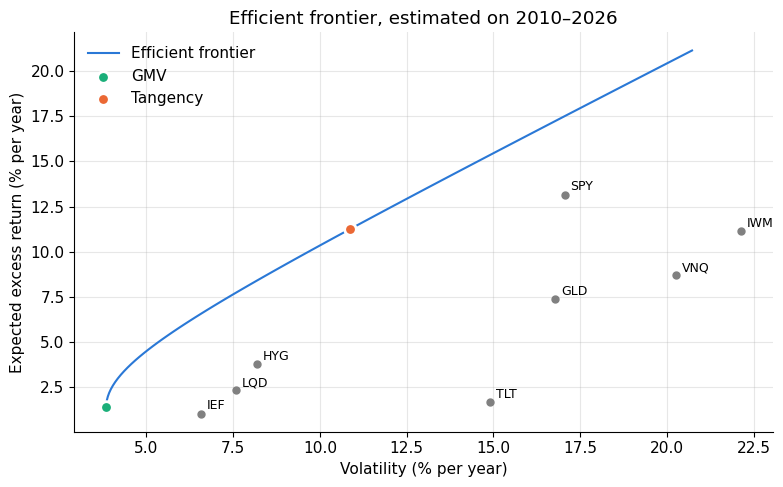

In [3]:
def stats(w):
    return w @ mu, np.sqrt(w @ Sigma @ w)          # (mu_p, sigma_p)

a_values = np.linspace(0, 2.0, 100)                # from GMV (a=0) upwards: the efficient half
frontier = np.array([stats(a * w_tan + (1 - a) * w_gmv) for a in a_values])   # two-fund theorem

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontier[:, 1] * 100, frontier[:, 0] * 100, color=COLORS[0], label="Efficient frontier")
ax.scatter(np.sqrt(np.diag(Sigma)) * 100, mu * 100, color="grey", s=25, zorder=3)
for t in assets:                                   # label each single asset
    ax.annotate(t, (np.sqrt(Sigma.loc[t, t]) * 100, mu[t] * 100), xytext=(4, 3),
                textcoords="offset points", fontsize=9)
for name, w, c in [("GMV", w_gmv, COLORS[2]), ("Tangency", w_tan, COLORS[1])]:
    r_, s_ = stats(w)
    ax.scatter(s_ * 100, r_ * 100, color=c, s=70, zorder=4, edgecolor="white", linewidth=2, label=name)
ax.set_xlabel("Volatility (% per year)")
ax.set_ylabel("Expected excess return (% per year)")
ax.set_title("Efficient frontier, estimated on 2010–2026")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

On paper the frontier dominates every single asset: for the volatility of any ETF, some mix offers a higher return. The question is whether we can trust it.

### 4.4 How stable are the weights?

We **bootstrap**: resample the daily returns with replacement 300 times, re-estimate $\mu$ and $\Sigma$ each time, and recompute the weights. Each resample is a dataset that could plausibly have happened instead. The spread of weights shows how much they depend on luck.

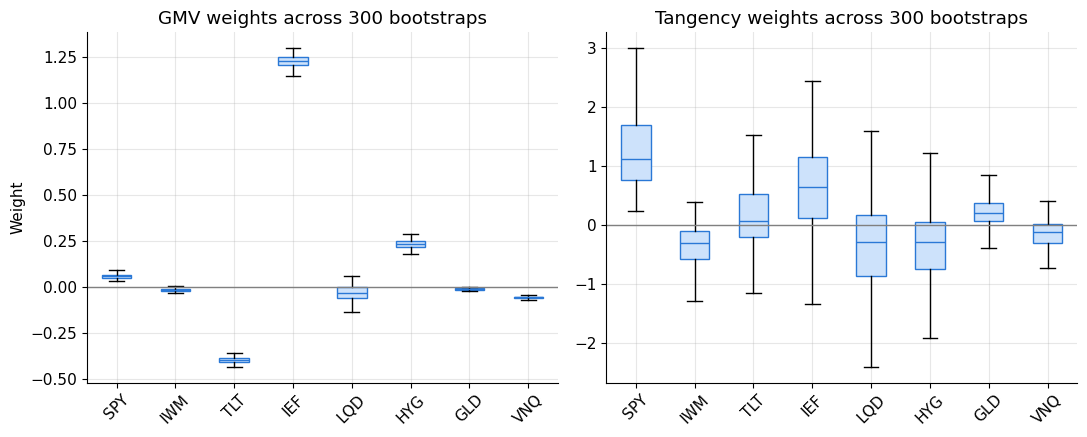

GMV: typical (median) width of the 90% range across assets = 5%
Tangency: typical (median) width of the 90% range across assets = 543%


In [4]:
rng = np.random.default_rng(1)
boot = {"GMV": [], "Tangency": []}
for _ in range(300):
    sample = excess.iloc[rng.integers(0, len(excess), len(excess))]   # resample days with replacement
    m, S = estimate(sample)
    boot["GMV"].append(gmv_weights(S))
    boot["Tangency"].append(tangency_weights(m, S))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, name in zip(axes, boot):
    W = pd.DataFrame(boot[name])
    W = W.clip(-3, 3)        # cap extreme values so the plot stays readable
    ax.boxplot(W.values, labels=assets, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="#cde2fb", color=COLORS[0]), medianprops=dict(color=COLORS[0]))
    ax.axhline(0, color="grey", linewidth=1)
    ax.set_title(f"{name} weights across 300 bootstraps")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Weight")
plt.tight_layout()
plt.show()

for name in boot:
    W = pd.DataFrame(boot[name])
    width = W.quantile(0.95) - W.quantile(0.05)              # range covering 90% of bootstraps
    print(f"{name}: typical (median) width of the 90% range across assets = {width.median():.0%}")

The contrast is the main lesson of this notebook:

- **GMV weights barely move** across resamples (a few percentage points). The covariance matrix is estimated precisely from 16 years of daily data.
- **Tangency weights swing wildly.** Most assets can be strongly long in one plausible history and strongly short in another. In some resamples $\mathbf 1^\top\Sigma^{-1}\mu$ is close to zero, and the weights explode to many times the capital. That is why the typical 90% range is several hundred percent wide (the plot caps weights at ±3).

The difference comes almost entirely from $\mu$. Expected returns are much harder to estimate than risk.

### 4.5 Out-of-sample test

The real test: estimate on 2010–2017, hold those weights through 2018–2026, and compare with simply splitting money equally.

In [5]:
train, test = excess[:"2017"], excess["2018":]
m_tr, S_tr = estimate(train)
portfolios = {
    "Equal weight": pd.Series(1 / len(assets), index=assets),
    "GMV": gmv_weights(S_tr),
    "Tangency": tangency_weights(m_tr, S_tr),
}

rows = {}
for name, w in portfolios.items():
    r_test = test @ w                                            # out-of-sample daily excess returns
    planned_sr = (w @ m_tr) / np.sqrt(w @ S_tr @ w)              # what the optimiser promised
    rows[name] = {"In-sample Sharpe": planned_sr,
                  "Out-of-sample Sharpe": np.sqrt(252) * r_test.mean() / r_test.std(),
                  "Out-of-sample vol": r_test.std() * np.sqrt(252),
                  "Max |weight|": w.abs().max()}
pd.DataFrame(rows).T.round(2)

,In-sample Sharpe,Out-of-sample Sharpe,Out-of-sample vol,Max |weight|
Equal weight,1.19,0.40,0.10,0.12
GMV,1.18,0.11,0.05,1.00
Tangency,1.67,0.44,0.08,0.52


- **Every in-sample promise was too optimistic.** The tangency portfolio promised a Sharpe ratio of 1.67 and delivered 0.44. Part of this is the period: 2010–2017 was unusually good for both stocks and bonds.
- **Equal weighting (0.40) did almost as well as the tangency portfolio (0.44)**, with no estimation at all and no position above 12%. The optimiser's extra complexity bought very little.
- **GMV did what it was designed to do**: it had the lowest volatility (5%). But its 100% bet on IEF was hit by the 2022 rate rise, leaving a Sharpe ratio of only 0.11.

One 8-year test is a single draw, so don't read too much into the exact ranking. The robust conclusion is the gap between promised and delivered performance.

## 5. Takeaways and where it breaks

- **The theory is right; the inputs are the problem.** Markowitz is optimal *if* you know $\mu$ and $\Sigma$. You never do.
- **Expected returns are the weak link.** The GMV portfolio ignores $\mu$ and is far more stable than the tangency portfolio.
- **Optimisers amplify noise.** Large long-short positions in similar assets (here, the two Treasury funds) are a sign the optimiser is exploiting estimation error, not real opportunities.
- **Fixes covered next in this track:** better covariance estimates (P2 shrinkage), methods that ignore $\mu$ altogether (P3 risk parity), and constraints such as no short selling or maximum weights.
- **Not covered here:** transaction costs of rebalancing, and the fact that $\mu$ and $\Sigma$ change over time (notebook 3).

**What you could build:** a "portfolio lab" where the team compares allocation methods on the same assets, always reporting out-of-sample results and weight stability next to the in-sample optimum.